In [18]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from scipy import stats

# 1. Load the data
df = pd.read_csv('Universities.csv')

# 2. Remove records with missing values
print("Original shape:", df.shape)
df_clean = df.dropna()
print("After removing missing values:", df_clean.shape)

# 3. Remove duplicate records
df_clean = df_clean.drop_duplicates()
print("After removing duplicates:", df_clean.shape)
df.head(5)

# 4. Fix data types
# Identify numeric columns that might be stored as strings
numeric_cols = df_clean.select_dtypes(include=[np.number]).columns.tolist()
for col in numeric_cols:
    df_clean[col] = pd.to_numeric(df_clean[col], errors='coerce')

# Convert categorical columns to proper types
categorical_cols = ['College Name', 'State']
for col in categorical_cols:
    df_clean[col] = df_clean[col].astype('category')

# 5. Standardize formats
# Clean college names (remove extra spaces, standardize capitalization)
df_clean['College Name'] = df_clean['College Name'].str.strip().str.title()

# Standardize state abbreviations (convert to uppercase)
df_clean['State'] = df_clean['State'].str.upper()

# 6. Remove outliers using z-score (for numeric columns)
z_scores = stats.zscore(df_clean.select_dtypes(include=[np.number]))
abs_z_scores = np.abs(z_scores)
filtered_entries = (abs_z_scores < 3).all(axis=1)  # Keep rows where all z-scores < 3
df_clean = df_clean[filtered_entries]
print("After removing outliers:", df_clean.shape)

# 7. Normalize the numeric data
# Select numeric columns to normalize (excluding categorical and identifier columns)
numeric_cols_to_normalize = [col for col in numeric_cols if col not in categorical_cols + ['Public (1)/ Private (2)']]

# Option 1: Standardization (mean=0, std=1)
scaler = StandardScaler()
df_clean[numeric_cols_to_normalize] = scaler.fit_transform(df_clean[numeric_cols_to_normalize])

# Option 2: Min-Max Scaling (to range [0,1])
# scaler = MinMaxScaler()
# df_clean[numeric_cols_to_normalize] = scaler.fit_transform(df_clean[numeric_cols_to_normalize])

# 8. Save the cleaned and processed data
df_clean.to_csv('Universities_processed.csv', index=False)

# Display summary
print("\nFinal cleaned dataset:")
print(df_clean.info())
print("\nSample of cleaned data:")
print(df_clean.head())

Original shape: (1302, 20)
After removing missing values: (471, 20)
After removing duplicates: (471, 20)
After removing outliers: (420, 20)

Final cleaned dataset:
<class 'pandas.core.frame.DataFrame'>
Index: 420 entries, 0 to 1301
Data columns (total 20 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   College Name              420 non-null    object 
 1   State                     420 non-null    object 
 2   Public (1)/ Private (2)   420 non-null    int64  
 3   # appli. rec'd            420 non-null    float64
 4   # appl. accepted          420 non-null    float64
 5   # new stud. enrolled      420 non-null    float64
 6   % new stud. from top 10%  420 non-null    float64
 7   % new stud. from top 25%  420 non-null    float64
 8   # FT undergrad            420 non-null    float64
 9   # PT undergrad            420 non-null    float64
 10  in-state tuition          420 non-null    float64
 11  out-of-state tu

<ipython-input-18-c59dc2515f91>:50: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_clean[numeric_cols_to_normalize] = scaler.fit_transform(df_clean[numeric_cols_to_normalize])


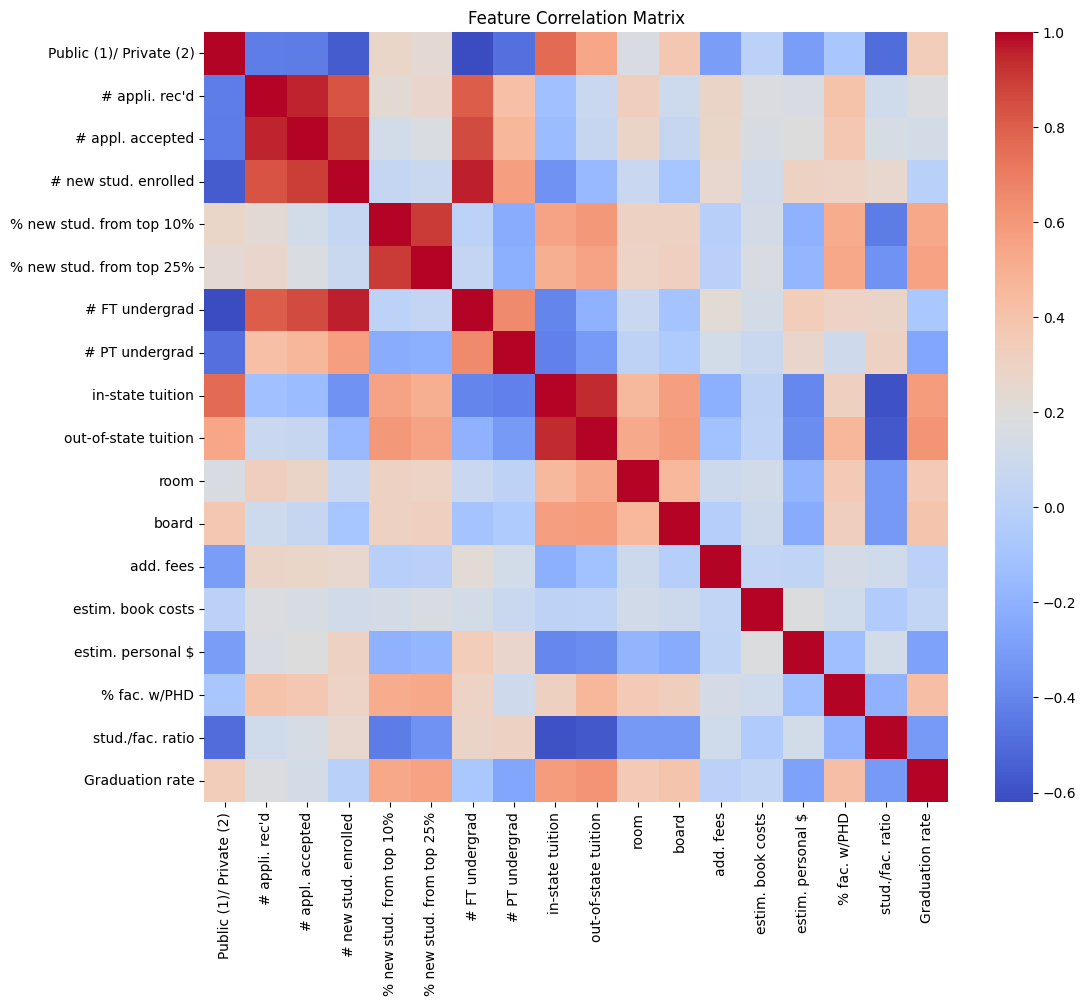


Top features correlated with Graduation Rate:
out-of-state tuition        0.615119
in-state tuition            0.586047
% new stud. from top 25%    0.562383
% new stud. from top 10%    0.532485
% fac. w/PHD                0.426871
board                       0.396387
room                        0.357993
Public (1)/ Private (2)     0.340906
stud./fac. ratio            0.313626
estim. personal $           0.283579
Name: Graduation rate, dtype: float64

Top 10 features using SelectKBest (f_regression):
Index(['Public (1)/ Private (2)', '% new stud. from top 10%',
       '% new stud. from top 25%', '# PT undergrad', 'in-state tuition',
       'out-of-state tuition', 'room', 'board', '% fac. w/PHD',
       'stud./fac. ratio'],
      dtype='object')

Top 10 features using SelectKBest (mutual_info_regression):
Index(['Public (1)/ Private (2)', '# appli. rec'd', '# appl. accepted',
       '# new stud. enrolled', '% new stud. from top 10%',
       '% new stud. from top 25%', '# FT undergrad', 

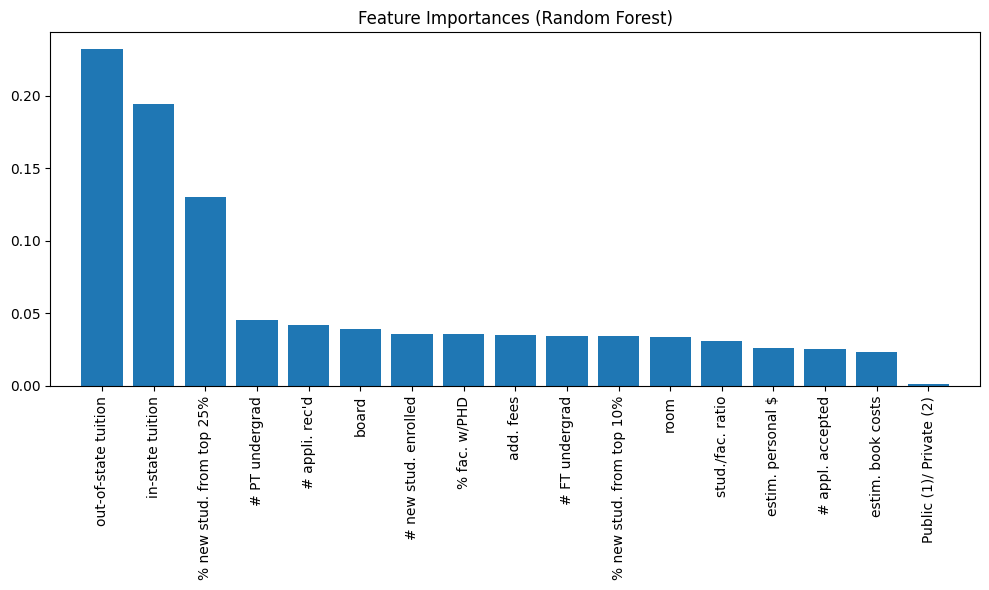


Top features based on combined selection methods:
                          Correlation  F_Regression  Mutual_Info  RFE_Support  \
out-of-state tuition         1.000000      1.000000     1.000000         True   
in-state tuition             0.952355      0.905171     0.968844         True   
% new stud. from top 25%     0.913575      0.737165     0.833918         True   
% new stud. from top 10%     0.864577      0.603704     0.966628         True   
board                        0.641537      0.339150     0.292785        False   
% fac. w/PHD                 0.691495      0.319156     0.129217         True   
Public (1)/ Private (2)      0.550615      0.281339     0.423910        False   
stud./fac. ratio             0.505907      0.163118     0.453582        False   
room                         0.578617      0.205331     0.167044        False   
estim. personal $            0.456667      0.147085     0.253636        False   
# PT undergrad               0.425018      0.153776     0.

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_selection import SelectKBest, f_regression, mutual_info_regression, RFE
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

# Load the dataset
df = pd.read_csv('Universities_processed.csv')

# Separate features and target
X = df.drop(['College Name', 'State', 'Graduation rate'], axis=1)
y = df['Graduation rate']

# Split data into train and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Standardize the data
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Feature selection methods
# 1. Correlation Analysis
plt.figure(figsize=(12, 10))
# Select only numeric features for correlation analysis
numeric_features = df.select_dtypes(include=np.number)
correlation_matrix = numeric_features.corr()  # Calculate correlation on numeric features only
sns.heatmap(correlation_matrix, annot=False, cmap='coolwarm')
plt.title('Feature Correlation Matrix')
plt.show()

# Get top correlated features with target
correlation_with_target = numeric_features.corr()['Graduation rate'].abs().sort_values(ascending=False) # Select numeric features
print("\nTop features correlated with Graduation Rate:")
print(correlation_with_target[1:11])  # Exclude the target itself


# 2. SelectKBest with f_regression
selector_f = SelectKBest(score_func=f_regression, k=10)
selector_f.fit(X_train_scaled, y_train)
selected_features_f = X.columns[selector_f.get_support()]
scores_f = selector_f.scores_

print("\nTop 10 features using SelectKBest (f_regression):")
print(selected_features_f)

# 3. SelectKBest with mutual_info_regression
selector_mi = SelectKBest(score_func=mutual_info_regression, k=10)
selector_mi.fit(X_train_scaled, y_train)
selected_features_mi = X.columns[selector_mi.get_support()]
scores_mi = selector_mi.scores_

print("\nTop 10 features using SelectKBest (mutual_info_regression):")
print(selected_features_mi)

# 4. Recursive Feature Elimination (RFE) with Linear Regression
estimator = LinearRegression()
selector_rfe = RFE(estimator, n_features_to_select=10, step=1)
selector_rfe.fit(X_train_scaled, y_train)
selected_features_rfe = X.columns[selector_rfe.support_]

print("\nTop 10 features using RFE with Linear Regression:")
print(selected_features_rfe)

# 5. Feature Importance with Random Forest
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train_scaled, y_train)
importances = rf.feature_importances_
indices = np.argsort(importances)[::-1]

print("\nFeature ranking with Random Forest:")
for f in range(X_train_scaled.shape[1]):
    print(f"{f+1}. {X.columns[indices[f]]} ({importances[indices[f]]:.4f})")

# Plot feature importances
plt.figure(figsize=(10, 6))
plt.title("Feature Importances (Random Forest)")
plt.bar(range(X_train_scaled.shape[1]), importances[indices], align="center")
plt.xticks(range(X_train_scaled.shape[1]), X.columns[indices], rotation=90)
plt.xlim([-1, X_train_scaled.shape[1]])
plt.tight_layout()
plt.show()

# Combine results from all methods
feature_scores = pd.DataFrame(index=X.columns)
feature_scores['Correlation'] = correlation_with_target[X.columns]
feature_scores['F_Regression'] = scores_f
feature_scores['Mutual_Info'] = scores_mi
feature_scores['RFE_Support'] = selector_rfe.support_
feature_scores['RF_Importance'] = importances

# Normalize scores (except RFE which is binary)
for col in ['Correlation', 'F_Regression', 'Mutual_Info', 'RF_Importance']:
    feature_scores[col] = (feature_scores[col] - feature_scores[col].min()) / \
                          (feature_scores[col].max() - feature_scores[col].min())

# Calculate combined score (excluding RFE)
feature_scores['Combined_Score'] = (feature_scores['Correlation'] +
                                   feature_scores['F_Regression'] +
                                   feature_scores['Mutual_Info'] +
                                   feature_scores['RF_Importance']) / 4

# Sort by combined score
feature_scores = feature_scores.sort_values('Combined_Score', ascending=False)

print("\nTop features based on combined selection methods:")
print(feature_scores.head(15))

# Select top features based on combined score
top_features = feature_scores.head(10).index.tolist()
print("\nRecommended top features to use:")
print(top_features)

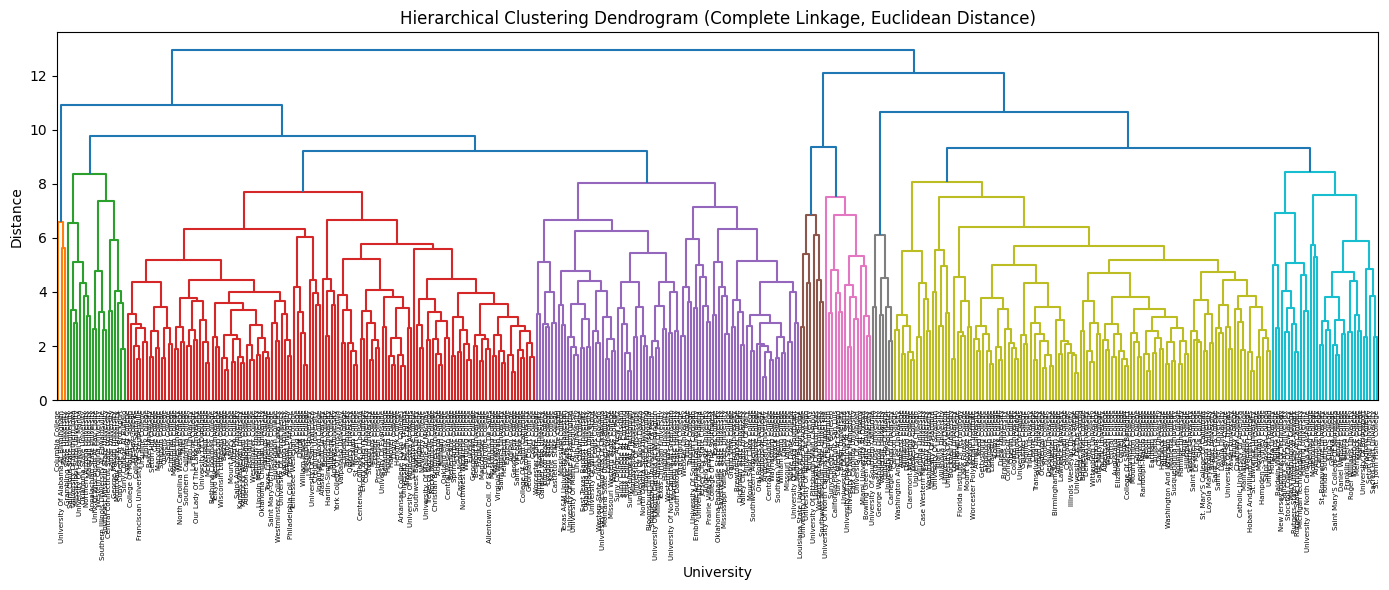

                     College Name  Cluster
0       Alaska Pacific University        2
1  University Of Alaska Southeast        2
2     Birmingham-Southern College        4
3              Huntingdon College        2
4               Talladega College        2


In [17]:
import pandas as pd
import numpy as np
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster
import matplotlib.pyplot as plt

# 1. Load the data
df = pd.read_csv('Universities_processed.csv')

# 2. Select features for clustering (exclude non-numeric columns)
# For demonstration, let's drop 'College Name' and 'State'
features = df.drop(['College Name', 'State'], axis=1)

# 3. Perform hierarchical clustering
Z = linkage(features, method='complete', metric='euclidean')

# 4. Plot the dendrogram
plt.figure(figsize=(14, 6))
dendrogram(Z, labels=df['College Name'].values, leaf_rotation=90)
plt.title('Hierarchical Clustering Dendrogram (Complete Linkage, Euclidean Distance)')
plt.xlabel('University')
plt.ylabel('Distance')
plt.tight_layout()
plt.show()

# 5. Assign clusters (for example, 4 clusters)
clusters = fcluster(Z, t=4, criterion='maxclust')
df['Cluster'] = clusters

# 6. Show first few rows with cluster assignments
print(df[['College Name', 'Cluster']].head())
